# FMitF Factor Analysis

## Design

- **Short naming**: `t5h3f0.1i0.1` (txn/hops/forloop/ifelseprob)
- **Factors**: only REAL generator params (branch_count is output, not input)
- **Small ranges** for quick testing (expand after validation)
- All figures saved as PDF


## 1. Setup


In [13]:
import os, sys, json, subprocess, shutil, re
from pathlib import Path

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

ROOT = Path('/Users/coned/Code/FMitF_rs')
GENERATOR = ROOT / 'examples' / 'gen_transact.py'
BASE = ROOT / 'tmp' / 'factor_sweep'
(BASE / 'input').mkdir(parents=True, exist_ok=True)
(BASE / 'output').mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 150
print('Backend:', matplotlib.get_backend())


Backend: inline


## 2. Factors & Naming

Compact name: `t{N}h{M}f{L}i{P}-s42`
where t=num_transactions, h=hops_max, f=for_loop_prob, i=if_prob
Factors are what we sweep (others held at base values).


In [14]:
# ===== BASE CONFIG (everything NOT swept) =====
CFG = {
    'num_transactions': 5,  # base; will be overridden when sweeping txn_count
    'tables_min': 2,
    'fields_per_table': 10,
    'pk_arity_min': 1, 'pk_arity_max': 2,
    'hops_min': 1, 'hops_max': 10,

    'hops_zipf_s': 2.0, 'hops_poisson_mean': 7.0,
    'op_read_p': 0.50, 'op_write_p': 0.20, 'op_inc_dec_p': 0.10, 'op_logical_p': 0.20,
    'for_loop_iters_min': 3, 'for_loop_iters_max': 5,
    'if_body_min_ops': 1, 'if_body_max_ops': 2,
    'for_loop_prob': 0.1,
    'if_prob': 0.1,
    'if_else_prob': 0.5,

    'seed': 42,
}

# Factors to sweep (REAL generator params only)
# Max ~8 values per factor for quick testing
FACTORS = {
    'txn_count':       [2, 5, 10, 20],
    'hops_max':        [2, 3, 5, 7, 10],
    'for_loop_prob':   [0.0, 0.1, 0.25, 0.5],
    'if_prob':         [0.0, 0.1, 0.25, 0.5],


}

# Short name encoding
#   t5h3f0.1i0.1-s42  (txn hops forloop if_prob seed)
def short_name(factor, value):
    h = CFG['hops_max'] if factor != 'hops_max' else value
    fl = CFG['for_loop_prob'] if factor != 'for_loop_prob' else value
    ip = CFG['if_prob'] if factor != 'if_prob' else value
    
    tags = [f't{value}' if factor == 'txn_count' else f't{CFG['num_transactions']}',
            f'h{value}' if factor == 'hops_max' else f'h{CFG['hops_max']}',
            f'f{fl}' if factor == 'for_loop_prob' else f'f{CFG['for_loop_prob']}',
            f'i{ip}' if factor == 'if_prob' else f'i{CFG['if_prob']}']
    
    parts = [t for t in tags if t]
    return '-'.join(parts) + '-s42.transact'

def parse_short(fname):
    # Parse short file name: t5h3f0.1i0.1-s42 -> dict
    base = fname.replace('-s42.transact', '')
    mapping = {'t': 'txn_count', 'h': 'hops_max', 'f': 'for_loop_prob', 'i': 'if_prob'}
    result = {}
    for part in base.split('-'):
        if not part: continue
        k = mapping.get(part[0])
        if k and len(part) > 1:
            try: val = float(part[1:])
            except ValueError: val = part[1:]
            if isinstance(val, (int, float)):
                try:
                    if val == int(val):
                        val = int(val)
                except (ValueError, TypeError):
                    pass
            result[k] = val
    return result

# Show summary
total = 0
for f, vals in FACTORS.items():
    exs = [short_name(f, v) for v in vals[:3]]
    print(f'  {f:>20s}: [{len(vals):2d}] values -> {", ".join(exs)}' +
          ('...' if len(vals) > 3 else ''))
    total += len(vals)
print(f'Total files: {total}')



             txn_count: [ 4] values -> t2-h10-f0.1-i0.1-s42.transact, t5-h10-f0.1-i0.1-s42.transact, t10-h10-f0.1-i0.1-s42.transact...
              hops_max: [ 5] values -> t5-h2-f0.1-i0.1-s42.transact, t5-h3-f0.1-i0.1-s42.transact, t5-h5-f0.1-i0.1-s42.transact...
         for_loop_prob: [ 4] values -> t5-h10-f0.0-i0.1-s42.transact, t5-h10-f0.1-i0.1-s42.transact, t5-h10-f0.25-i0.1-s42.transact...
               if_prob: [ 4] values -> t5-h10-f0.1-i0.0-s42.transact, t5-h10-f0.1-i0.1-s42.transact, t5-h10-f0.1-i0.25-s42.transact...
Total files: 17


## 3. I/O Helpers

Based on actual data.json structure:
- `c_edge_verifications[]` has direct `duration_ms` (float), `result` ('Pass'/'Error')
- `summary` has `verification_pass/total`, `sc_c_edges`, etc.



In [15]:
def generate_transact(factor, value):
    fname = short_name(factor, value)
    out = BASE / 'input' / fname
    args = ['python3', str(GENERATOR), '--seed', '42']
    for k, v in CFG.items():
        args += ['--' + k.replace('_', '-'), str(v)]
    # Override the factor being swept
    cli = factor.replace('_', '-')
    if cli == 'txn-count': cli = 'num-transactions'
    args += ['--' + cli, str(value)]
    args += ['--out', str(out)]
    r = subprocess.run(args, capture_output=True, text=True)
    if r.returncode != 0:
        print(f'  [GEN ERR] {fname}: {r.stderr[:200]}')
    return out

def compile_transact(fname):
    tpath = BASE / 'input' / fname
    out_dir = BASE / 'output' / fname.replace('.transact', '')
    if out_dir.exists(): shutil.rmtree(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    args = ['cargo', 'run', '--release', '--',
            str(tpath), str(out_dir), '--clear-cache']
    try:
        r = subprocess.run(args, capture_output=True, text=True,
                           timeout=300, cwd=str(ROOT))
    except subprocess.TimeoutExpired:
        print(f'  [TIMEOUT] {fname}')
        return None
    dj = out_dir / 'data.json'
    if dj.exists() and dj.stat().st_size > 100:
        print(f'  [OK] {fname}')
        return out_dir, dj
    print(f'  [FAIL] {fname}')
    return None

def extract_records(dj_path):
    with open(dj_path) as f: data = json.load(f)
    recs = []
    for e in data.get('c_edge_verifications', []):
        recs.append(dict(e))  # keep raw field names: duration_ms, result, branch_count, etc.
    return recs, data.get('summary', {})

def make_file_summary(recs, summary, factor, value):
    n = len(recs)
    if n == 0:
        return {'factor': factor, 'value': value, 'num_c_edges': 0}
    
    # duration_ms is a direct float
    times = [r.get('duration_ms', 0) for r in recs]
    times = [t for t in times if isinstance(t, (int, float)) and t > 0]
    
    pass_count = sum(1 for r in recs if r.get('result') == 'Pass')
    errs = n - pass_count
    
    bcs = [r.get('branch_count', 0) or 0 for r in recs]
    loops = [r.get('has_loop', False) for r in recs]
    dr = [r.get('db_read_count', 0) or 0 for r in recs]
    dw = [r.get('db_write_count', 0) or 0 for r in recs]
    
    st = sorted(times) if times else [0]
    
    return {
        'factor': factor, 'value': value,
        'num_c_edges': n,
        'num_pass': pass_count, 'num_error': errs,
        'commutative_pct': 100.0 * pass_count / n if n else 0,
        'total_time_ms': sum(times),
        'avg_time_ms': sum(times) / len(times) if times else 0,
        'median_time_ms': st[len(st)//2] if st else 0,
        'max_time_ms': max(times) if times else 0,
        'avg_branch_count': sum(bcs) / n if n else 0,
        'max_branch_count': max(bcs) if bcs else 0,
        'pct_with_loop': sum(1 for l in loops if l) / n * 100 if n else 0,
        'sum_db_read': sum(dr), 'sum_db_write': sum(dw),
        'sc_c_edges': summary.get('sc_c_edges', 0),
        'function_count': summary.get('function_count', 0),
        'hop_count': summary.get('hop_count', 0),
    }

print('I/O helpers ready.')





I/O helpers ready.


## 4. Sweep Runner

`RUN_SWEEP = True` to generate + compile all.
Set to `False` after first run to skip and load existing data.


In [16]:
RUN_SWEEP = True

all_file_summaries = []
all_cedge_records = []

if RUN_SWEEP:
    print(f'Starting sweep: {total} files')
    for factor, values in FACTORS.items():
        print(f'--- {factor} ---')
        for value in values:
            fname = short_name(factor, value)
            tp = generate_transact(factor, value)
            if not tp.exists():
                print(f'  SKIP gen: {fname}'); continue
            result = compile_transact(fname)
            if not result:
                print(f'  SKIP comp: {fname}'); continue
            out_dir, dj = result
            recs, summary = extract_records(dj)
            for r in recs: r['variant_name'] = fname
            all_cedge_records.extend(recs)
            fs = make_file_summary(recs, summary, factor, value)
            all_file_summaries.append(fs)
            print(f'  {fname}: {fs["num_c_edges"]} c-edges, '
                  f'{fs["commutative_pct"]:.0f}% comm, {fs["total_time_ms"]:.0f}ms')
        print()
    print(f'Done: {len(all_file_summaries)} compiled')
    
    with open(BASE / 'all_file_summaries.json', 'w') as f:
        json.dump(all_file_summaries, f)
    with open(BASE / 'all_cedge_records.json', 'w') as f:
        json.dump(all_cedge_records, f)
else:
    print('SWEEP SKIPPED')
    p1 = BASE / 'all_file_summaries.json'
    p2 = BASE / 'all_cedge_records.json'
    if p1.exists():
        with open(p1) as f: all_file_summaries = json.load(f)
    if p2.exists():
        with open(p2) as f: all_cedge_records = json.load(f)
    print(f'Loaded: {len(all_file_summaries)} files, '
          f'{len(all_cedge_records)} c-edge records')



Starting sweep: 17 files
--- txn_count ---
  [OK] t2-h10-f0.1-i0.1-s42.transact
  t2-h10-f0.1-i0.1-s42.transact: 1 c-edges, 100% comm, 242ms
  [OK] t5-h10-f0.1-i0.1-s42.transact
  t5-h10-f0.1-i0.1-s42.transact: 5 c-edges, 80% comm, 2511ms
  [OK] t10-h10-f0.1-i0.1-s42.transact
  t10-h10-f0.1-i0.1-s42.transact: 51 c-edges, 25% comm, 23929ms
  [OK] t20-h10-f0.1-i0.1-s42.transact
  t20-h10-f0.1-i0.1-s42.transact: 122 c-edges, 47% comm, 66163ms

--- hops_max ---
  [OK] t5-h2-f0.1-i0.1-s42.transact
  t5-h2-f0.1-i0.1-s42.transact: 1 c-edges, 0% comm, 369ms
  [OK] t5-h3-f0.1-i0.1-s42.transact
  t5-h3-f0.1-i0.1-s42.transact: 7 c-edges, 0% comm, 3138ms
  [OK] t5-h5-f0.1-i0.1-s42.transact
  t5-h5-f0.1-i0.1-s42.transact: 5 c-edges, 80% comm, 2197ms
  [OK] t5-h7-f0.1-i0.1-s42.transact
  t5-h7-f0.1-i0.1-s42.transact: 5 c-edges, 80% comm, 2059ms
  [OK] t5-h10-f0.1-i0.1-s42.transact
  t5-h10-f0.1-i0.1-s42.transact: 5 c-edges, 80% comm, 2481ms

--- for_loop_prob ---
  [OK] t5-h10-f0.0-i0.1-s42.transact

## 5. Load & Inspect


In [17]:
# Load if not already in memory
if not all_file_summaries:
    p1 = BASE / 'all_file_summaries.json'
    p2 = BASE / 'all_cedge_records.json'
    if p1.exists():
        with open(p1) as f: all_file_summaries = json.load(f)
    if p2.exists():
        with open(p2) as f: all_cedge_records = json.load(f)

df = pd.DataFrame(all_file_summaries)
dce = pd.DataFrame(all_cedge_records)

# Convert numeric columns
for c in ['value', 'total_time_ms', 'avg_time_ms', 'num_c_edges', 'commutative_pct', 'avg_branch_count', 'sum_db_read', 'sum_db_write']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Convert c-edge columns
for c in ['duration_ms', 'branch_count', 'db_read_count', 'db_write_count', 'boogie_file_len', 'real_procedure_len']:
    if c in dce.columns:
        dce[c] = pd.to_numeric(dce[c], errors='coerce')

print(f'{len(df)} files, {len(dce)} c-edge records')
for f in df['factor'].unique():
    sub = df[df['factor'] == f]
    v = sub['total_time_ms'].dropna()
    print(f'  {f:>20s}: n={len(sub)}, time_mean={v.mean():.0f}ms, comm={sub["commutative_pct"].mean():.0f}%')

# --- Sample C-edge records (from data.json) ---
if len(dce) > 0:
    print('\nSample c-edge records (raw from data.json):')
    sample = dce.head(3)
    # Show key numeric columns
    key_cols = ['duration_ms', 'result', 'branch_count', 'has_loop',
                'db_read_count', 'db_write_count', 'boogie_file_len',
                'real_procedure_len', 'source_function_id', 'target_function_id']
    available = [c for c in key_cols if c in sample.columns]
    print(sample[available].to_string(index=False))
else:
    print('No c-edge records found.')

df.to_csv(BASE / 'file_summary.csv', index=False)
print('Saved to ' + str(BASE / 'file_summary.csv'))


17 files, 274 c-edge records
             txn_count: n=4, time_mean=23211ms, comm=63%
              hops_max: n=5, time_mean=2049ms, comm=48%
         for_loop_prob: n=4, time_mean=5381ms, comm=54%
               if_prob: n=4, time_mean=4646ms, comm=57%

Sample c-edge records (raw from data.json):
 duration_ms result  branch_count  has_loop  db_read_count  db_write_count  boogie_file_len  real_procedure_len  source_function_id  target_function_id
  242.034208   Pass             0     False              0               2             8373                2011                  17                  17
  447.939042  Error             0     False              2               2            12528                4075                  20                  20
  461.402334   Pass             2     False              6               4            13596                5143                  20                  20
Saved to /Users/coned/Code/FMitF_rs/tmp/factor_sweep/file_summary.csv


## 6. save_fig Helper


In [18]:
def save_fig(fig, path):
    # Save as PDF.
    fig.savefig(str(path), dpi=150, format='pdf')
    print(f'  saved: {path}')
    plt.show()
    plt.close(fig)


## 7. `plot_bar(factor)` — Generic Bar Chart


  saved: /Users/coned/Code/FMitF_rs/tmp/factor_sweep/fig_bar_hopsmax.pdf


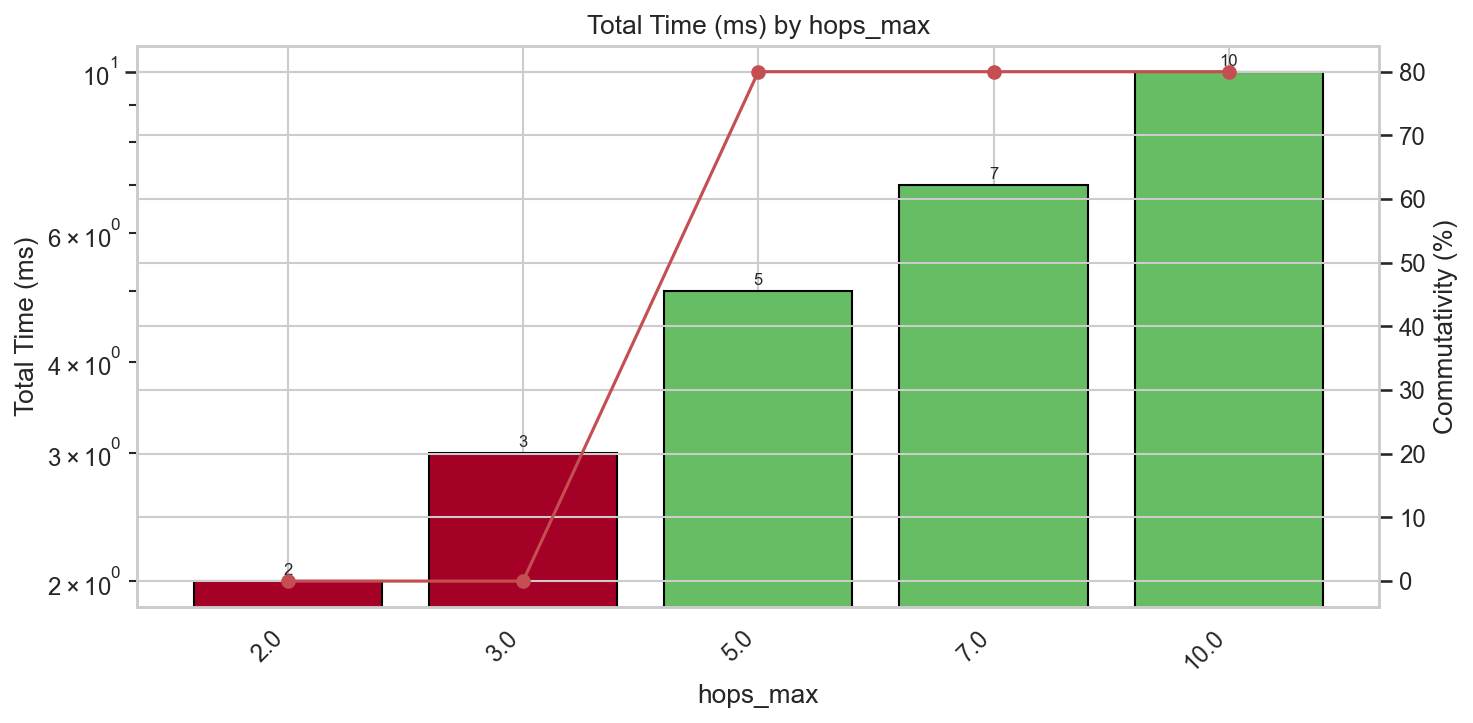

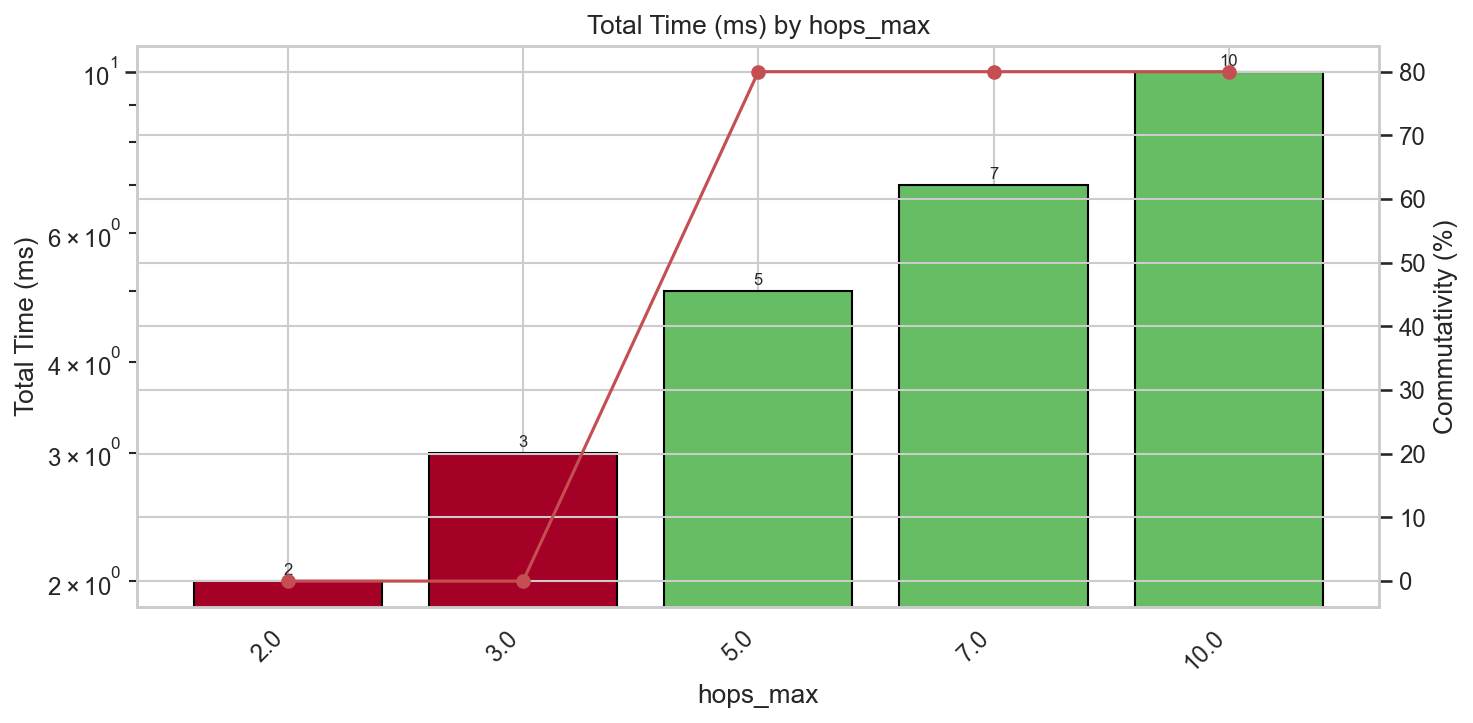

In [19]:
def plot_bar(factor, metric='total_time_ms', ax=None):
    # Bar chart: factor values vs a numeric metric.
    sub = df[df['factor'] == factor].copy()
    sub = sub.sort_values('value')
    if len(sub) == 0:
        print(f'No data for factor: {factor}'); return None
    
    labels = {'total_time_ms': 'Total Time (ms)',
              'avg_time_ms': 'Avg C-Edge Time (ms)',
              'num_c_edges': '# C-Edges',
              'commutative_pct': 'Commutativity (%)',
              'avg_branch_count': 'Avg Branch Count',
              'pct_with_loop': '% With Loops'}
    ylabel = labels.get(metric, metric)
    use_log = metric in ['total_time_ms', 'avg_time_ms', 'max_time_ms']
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
    else:
        fig = ax.get_figure()
    
    colors = plt.cm.RdYlGn(sub['commutative_pct'] / 100) if 'commutative_pct' in sub.columns else plt.cm.viridis(np.linspace(0.2, 0.8, len(sub)))
    
    bars = ax.bar(range(len(sub)), sub['value'].astype(float), color=colors, edgecolor='black')
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub['value'].astype(str), rotation=45, ha='right')
    ax.set_xlabel(factor)
    ax.set_ylabel(ylabel)
    
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.01 * max(h, 1),
               f'{h:.0f}', ha='center', va='bottom', fontsize=8)
    
    if use_log: ax.set_yscale('log')
    
    # Overlay commutativity as line
    if 'commutative_pct' in sub.columns:
        ax2 = ax.twinx()
        ax2.plot(range(len(sub)), sub['commutative_pct'], 'r-o', linewidth=1.5, markersize=6)
        ax2.set_ylabel('Commutativity (%)')
    
    ax.set_title(f'{ylabel} by {factor}')
    fig.tight_layout()
    save_fig(fig, BASE / f'fig_bar_{factor.replace("_", "")}.pdf')
    return fig

plot_bar('hops_max')


## 8. `plot_scatter(x, y)` — Scatter Plot


  saved: /Users/coned/Code/FMitF_rs/tmp/factor_sweep/fig_scatter_forloopprob.pdf


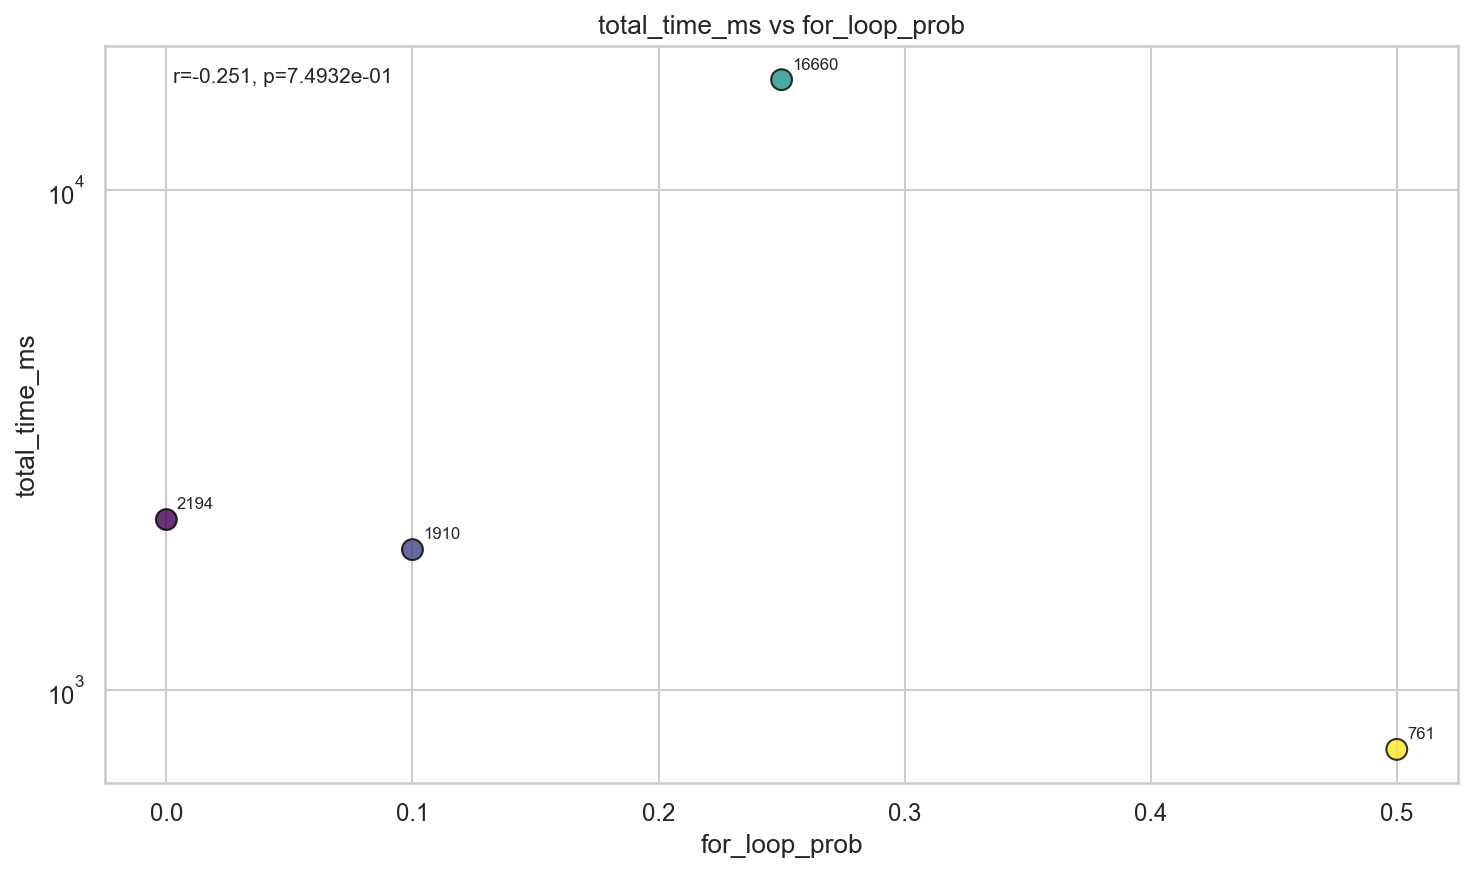

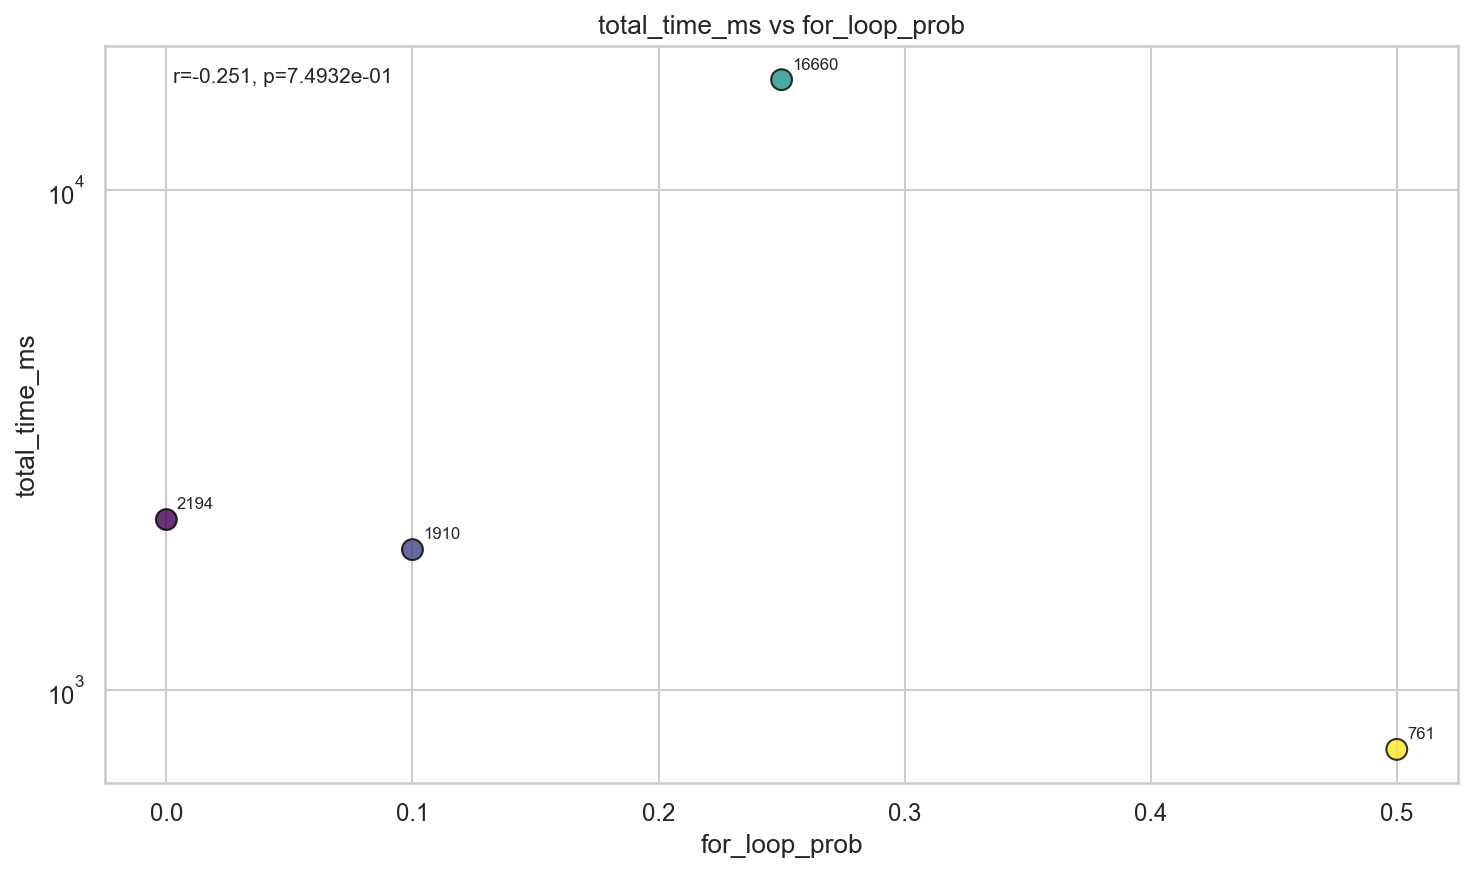

In [20]:
def plot_scatter(x_factor, y_factor='total_time_ms', ax=None):
    # Scatter: one factor vs a numeric metric.
    if x_factor in df['factor'].unique():
        sub = df[df['factor'] == x_factor].copy()
        if len(sub) < 3:
            print(f'Need >= 3 data points'); return None
        sub = sub.sort_values('value')
        x = sub['value'].astype(float)
        y = sub[y_factor].astype(float)
    else:
        sub = df.dropna(subset=[x_factor, y_factor])
        if len(sub) < 3: print('Not enough data'); return None
        x = sub[x_factor].astype(float)
        y = sub[y_factor].astype(float)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.get_figure()
    
    sc = ax.scatter(x, y, s=100, c=x/x.max() if x.max() > 0 else 0,
                   cmap='viridis', edgecolors='black', alpha=0.8)
    
    for xi, yi in zip(x, y):
        ax.annotate(f'{yi:.0f}', (xi, yi), fontsize=8, xytext=(5, 5), textcoords='offset points')
    
    ax.set_xlabel(x_factor)
    ax.set_ylabel(y_factor)
    ax.set_yscale('log')
    
    from scipy import stats
    valid = ~(np.isnan(x.values) | np.isnan(y.values))
    if valid.sum() > 3:
        r, p = stats.pearsonr(x.values[valid], np.log1p(y.values[valid]))
        ax.text(0.05, 0.95, f'r={r:.3f}, p={p:.4e}', transform=ax.transAxes, fontsize=10)
    
    ax.set_title(f'{y_factor} vs {x_factor}')
    fig.tight_layout()
    save_fig(fig, BASE / f'fig_scatter_{x_factor.replace("_", "")}.pdf')
    return fig

plot_scatter('for_loop_prob', 'total_time_ms')


## 9. `plot_correlation()` — Correlation Matrix


Strongest correlations with total_time_ms:
           num_c_edges: +0.997
            sc_c_edges: +0.997
           sum_db_read: +0.993
             hop_count: +0.991
          sum_db_write: +0.935
        function_count: +0.934
           avg_time_ms: +0.442
        median_time_ms: +0.256
      max_branch_count: +0.124
      avg_branch_count: +0.109
         pct_with_loop: -0.118
       commutative_pct: -0.261
  saved: /Users/coned/Code/FMitF_rs/tmp/factor_sweep/fig_correlation.pdf


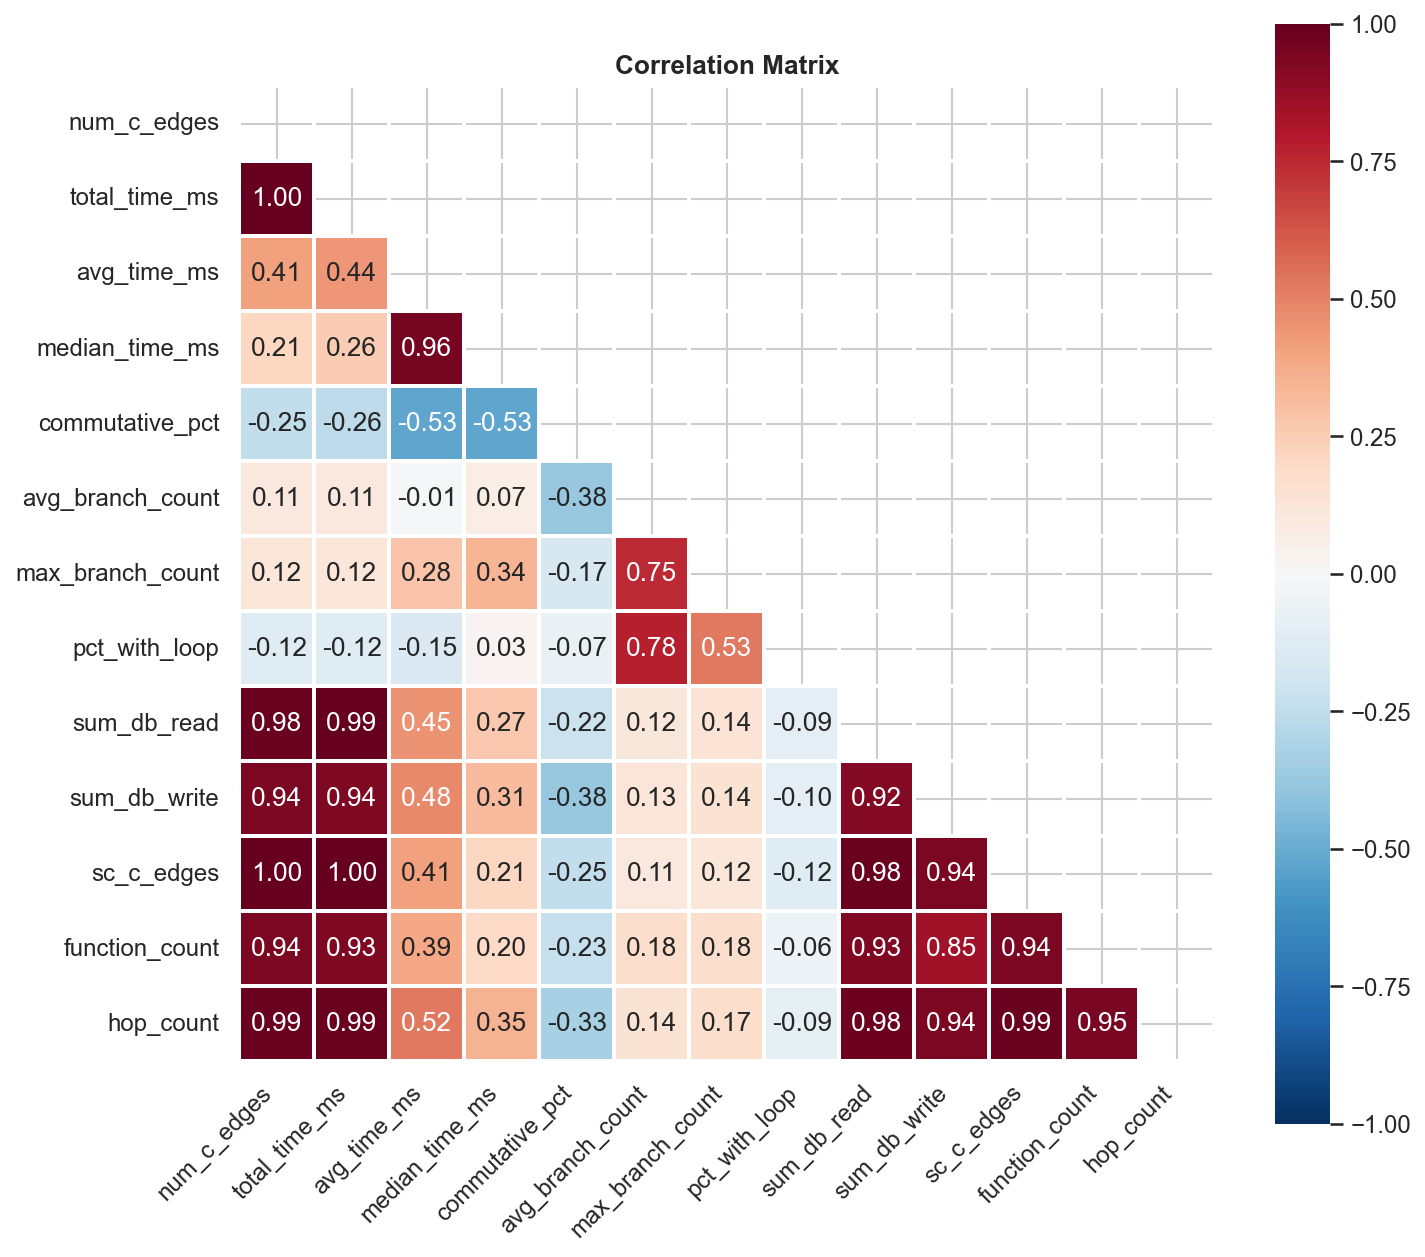

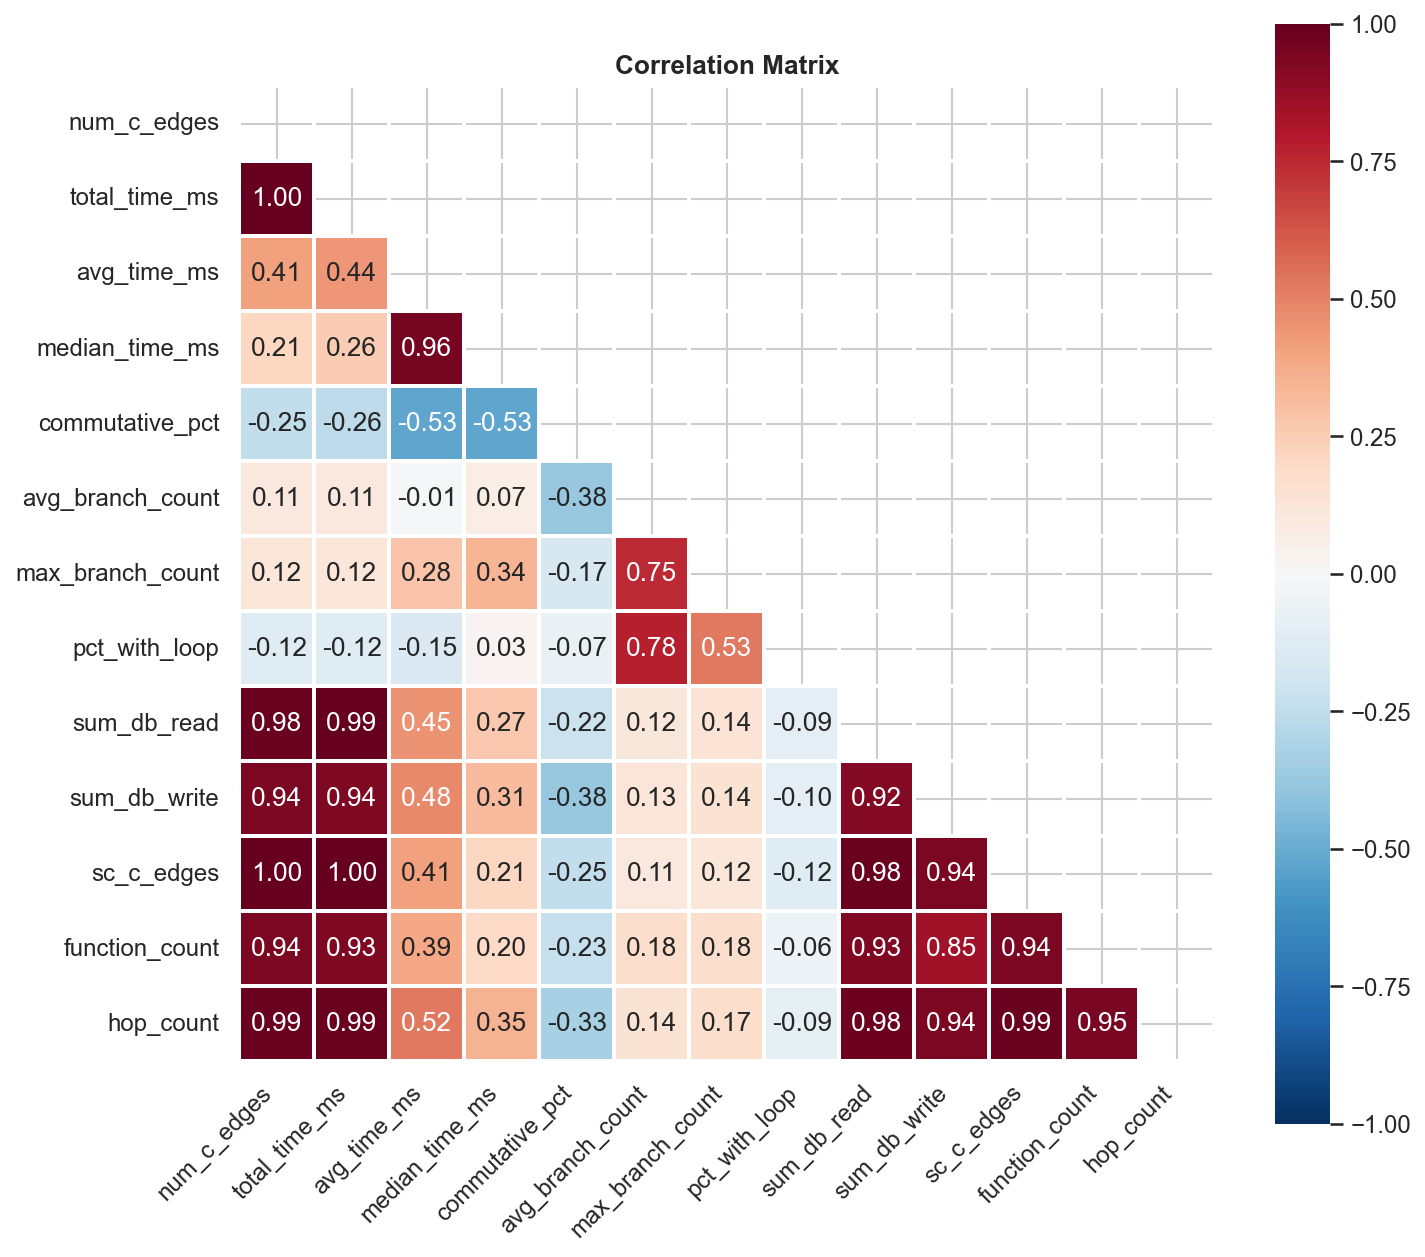

In [21]:
def plot_correlation():
    # Correlation heatmap.
    cols = ['num_c_edges', 'total_time_ms', 'avg_time_ms', 'median_time_ms',
            'commutative_pct', 'avg_branch_count', 'max_branch_count',
            'pct_with_loop', 'sum_db_read', 'sum_db_write',
            'sc_c_edges', 'function_count', 'hop_count']
    available = [c for c in cols if c in df.columns]
    
    ndf = df[available].copy()
    for c in available: ndf[c] = pd.to_numeric(ndf[c], errors='coerce')
    ndf = ndf.dropna()
    
    if len(ndf) < 3: print('Not enough data'); return None
    
    cm = ndf.corr()
    fig, ax = plt.subplots(figsize=(min(10, len(available)), min(10, len(available))))
    mask = np.triu(np.ones_like(cm, dtype=bool))
    sns.heatmap(cm, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
               vmin=-1, vmax=1, center=0, square=True, linewidths=1, ax=ax,
               cbar_kws={'shrink': 0.8})
    ax.set_title('Correlation Matrix', fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    fig.tight_layout()
    
    # Print strong correlations with total_time_ms
    if 'total_time_ms' in cm.columns:
        tc = cm['total_time_ms'].drop('total_time_ms').sort_values(ascending=False)
        print('Strongest correlations with total_time_ms:')
        for name, val in tc.items(): print(f'  {name:>20s}: {val:+.3f}')
    
    save_fig(fig, BASE / 'fig_correlation.pdf')
    return fig

plot_correlation()


## 10. `plot_regression(factors)` — Multi-Factor Regression


In [22]:
def plot_regression(predictors, target='total_time_ms'):
    # Linear regression.
    from sklearn.linear_model import LinearRegression
    
    rdf = df.copy()
    for p in predictors:
        if p not in rdf.columns:
            print(f'Unknown predictor: {p}'); return None
        rdf[p] = pd.to_numeric(rdf[p], errors='coerce')
    rdf[target] = pd.to_numeric(rdf[target], errors='coerce')
    
    rdf = rdf.dropna(subset=predictors + [target])
    
    if len(rdf) <= len(predictors) + 2:
        print(f'Need more data: {len(rdf)} rows'); return None
    
    X = rdf[predictors]
    y = np.log1p(rdf[target])
    
    model = LinearRegression().fit(X, y)
    r2 = model.score(X, y)
    
    coeffs = list(zip(predictors, model.coef_))
    coeffs.sort(key=lambda x: abs(x[1]), reverse=True)
    
    if not coeffs: return None
    
    fig, ax = plt.subplots(figsize=(10, max(5, len(coeffs) * 0.4)))
    nvs = [n for n, _ in reversed(coeffs)]
    vls = [v for _, v in reversed(coeffs)]
    colors = ['red' if v < 0 else 'green' for v in vls]
    
    bars = ax.barh(range(len(coeffs)), vls, color=colors, alpha=0.8)
    ax.set_yticks(range(len(coeffs)))
    ax.set_yticklabels(nvs)
    ax.set_xlabel('Coefficient (log-time scale)')
    ax.axvline(x=0, color='black', linewidth=0.5)
    for bar, val in zip(bars, vls):
        ax.text(bar.get_width() + 0.01 * abs(bar.get_width()) if bar.get_width() != 0 else 0.001,
               bar.get_y() + bar.get_height()/2, f'{val:+.4f}', va='center')
    ax.set_title(f'Regression: {target}')
    ax.invert_yaxis()
    fig.tight_layout()
    
    print(f'R2 = {r2:.4f}')
    for name, val in reversed(coeffs):
        impact = 'increases time' if val > 0 else 'decreases time'
        print(f'  {name:>20s}: {val:+.4f} ({impact})')
    
    save_fig(fig, BASE / 'fig_regression.pdf')
    return fig

plot_regression(['txn_count', 'hops_max', 'for_loop_prob'])


Unknown predictor: txn_count


## Usage

| Function | Example |
|----------|-------|
| `plot_bar(factor)` | `plot_bar('hops_max')` |
| `plot_scatter(x, y)` | `plot_scatter('for_loop_prob', 'total_time_ms')` |
| `plot_correlation()` | `plot_correlation()` |
| `plot_regression(preds)` | `plot_regression(['txn_count', 'hops_max'])` |


In [26]:
# Multi-factor C-Edge Scatter Gallery
# Each point = one C-edge verification.
# X-axis = actual code properties from data.json,
# Y-axis = verification time (duration_ms).

# --- 1. Load C-edge records (raw field names, no prefix) ---

all_records = []
recognized_dirs = [d for d in (BASE / "output").iterdir()
                   if d.is_dir() and d.name.startswith("t") and "-s42" in d.name]
for sub in sorted(recognized_dirs):
    dj = sub / "data.json"
    if dj.exists():
        try:
            with open(dj) as f:
                data = json.load(f)
        except Exception:
            continue
        for edge in data.get("c_edge_verifications", []):
            if "duration_ms" not in edge:
                continue
            rec = dict(edge)  # raw fields: duration_ms, result, branch_count,
                              # has_loop, db_read_count, db_write_count,
                              # boogie_file_len, real_procedure_len,
                              # source_function_id, target_function_id, etc.
            all_records.append(rec)

df = pd.DataFrame(all_records)

# Convert numeric columns
for c in ["duration_ms", "branch_count", "db_read_count", "db_write_count",
          "boogie_file_len", "real_procedure_len",
          "source_function_id", "target_function_id"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df["total_db_ops"] = pd.to_numeric(df.get("db_read_count", 0), errors="coerce") + \
                     pd.to_numeric(df.get("db_write_count", 0), errors="coerce")

print("%d c-edge records loaded\n" % len(df))

# --- 2. Color helper: green=Pass, red=Error ---

def edge_colors(df):
    return ["green" if r == "Pass" else "red" for r in df.get("result", "Pass")]

# --- 3. Plotting function: one panel = one parameter vs duration_ms ---

def plot_param_scatter(param, ax):
    if param not in df.columns:
        ax.text(0.5, 0.5, "no data", transform=ax.transAxes)
        return
    vals = pd.to_numeric(df[param], errors="coerce")
    mask = vals.notna()
    if not mask.any():
        ax.text(0.5, 0.5, "no data", transform=ax.transAxes)
        return
    vals_m = vals[mask].values.astype(float)
    times_m = df.loc[mask, "duration_ms"].values.astype(float)
    colors_all = edge_colors(df)
    colors_m = [colors_all[i] for i in range(len(mask)) if mask.iloc[i]]
    ax.scatter(vals_m, times_m, s=15, c=colors_m, alpha=0.6, edgecolors="none")
    ax.set_xlabel(param)
    ax.set_ylabel("duration_ms")
    ax.set_yscale("log")

# --- 4. Draw grid of subplots ---

# Use actual C-edge parameters from the data.json schema
params_to_plot = [
    "source_function_id",   # which source function
    "target_function_id",   # which target function
    "total_db_ops",         # db_read_count + db_write_count
    "boogie_file_len",      # compiled Boogie file size (bytes)
]

n = len(params_to_plot)
cols = 4
rows = 1

fig = plt.figure(figsize=(20, 5))
axes_list = [fig.add_subplot(rows, cols, i+1) for i in range(n)]

for idx, param in enumerate(params_to_plot):
    plot_param_scatter(param, axes_list[idx])
    axes_list[idx].set_title("duration_ms vs %s" % param)

# Legend
from matplotlib.lines import Line2D
ax_leg = axes_list[0]
leg = ax_leg.legend(handles=[
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor="green", markersize=8, label="Pass"),
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor="red", markersize=8, label="Error"),
], loc="upper right", framealpha=0.9)

fig.suptitle("C-Edge Verification Times by Code Properties",
             fontsize=16, y=1.02)
fig.tight_layout()

out = BASE / "fig_cedge_gallery.pdf"
fig.savefig(str(out), dpi=150, format="pdf")
fig.show()
plt.close(fig)

print("Saved fig_cedge_gallery.pdf (%.1f KB)" % (out.stat().st_size / 1024))


259 c-edge records loaded

Saved fig_cedge_gallery.pdf (26.7 KB)


/var/folders/kv/6dw98l5s6nb26lmvmgypsf1m0000gn/T/ipykernel_62655/3143201778.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
